Dataset: https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data?resource=download



### Import and load

In [1]:
import os, sys, math, textwrap, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

DATA_PATH = Path('AB_NYC_2019.csv')
MAP_PATH = Path('New_York_City_.png')
assert DATA_PATH.exists(), f"Dataset not found at {DATA_PATH}. Upload it to the runtime or adjust the path."


def load_data(path=DATA_PATH):
    df = pd.read_csv(path)
    return df

raw_df = load_data()
df = raw_df.copy()
print(f"Loaded {len(df):,} rows × {df.shape[1]} columns")

Loaded 48,895 rows × 16 columns


### Top 10 Most Reviewed Listings
Most of them are private rooms

In [2]:
top_reviewed = df.sort_values('number_of_reviews', ascending=False).head(10)[['id','name','room_type','price','number_of_reviews']]
print('Top 10 Most Reviewed Listings:')
top_reviewed

Top 10 Most Reviewed Listings:


,id,name,room_type,price,number_of_reviews
11759,9145202,Room near JFK Queen Bed,Private room,47,629
2031,903972,Great Bedroom in Manhattan,Private room,49,607
2030,903947,Beautiful Bedroom in Manhattan,Private room,49,597
2015,891117,Private Bedroom in Manhattan,Private room,49,594
13495,10101135,Room Near JFK Twin Beds,Private room,47,576
10623,8168619,Steps away from Laguardia airport,Private room,46,543
1879,834190,Manhattan Lux Loft.Like.Love.Lots.Look !,Private room,99,540
20403,16276632,Cozy Room Family Home LGA Airport NO CLEANING FEE,Private room,48,510
4870,3474320,Private brownstone studio Brooklyn,Entire home/apt,160,488
471,166172,LG Private Room/Family Friendly,Private room,60,480


### Top 10 Neighbourhoods by mean price
Neighborhoods that has fewer listings are more valuable.

In [3]:
nbh_detail = df.groupby('neighbourhood').agg(
    listings=('id','count'),
    mean_price=('price','mean'),
)
nbh_filtered = nbh_detail.sort_values('mean_price', ascending=False).head(10)
display(nbh_filtered)

print(f"Mean of all neighborhood mean prices: {nbh_detail['mean_price'].mean():.2f}")
average_listings_per_neighborhood = nbh_detail['listings'].mean()
print(f"The average number of listings per neighborhood is: {average_listings_per_neighborhood:.2f}")

,listings,mean_price
neighbourhood,,
Fort Wadsworth,1,800.000000
Woodrow,1,700.000000
Tribeca,177,490.638418
Sea Gate,7,487.857143
Riverdale,11,442.090909
Prince's Bay,4,409.500000
Battery Park City,70,367.557143
Flatiron District,80,341.925000
Randall Manor,19,336.000000


Mean of all neighborhood mean prices: 133.25
The average number of listings per neighborhood is: 221.24


### Neighbourhood Group Comparison Data
The more expensive the group of neighborhoods is, the more listings it has.

In [4]:
nbh_grp = df.groupby('neighbourhood_group').agg(
    listings=('id','count'),
    median_price=('price','median'),
    mean_price=('price','mean'),
).sort_values('median_price', ascending=False)
nbh_grp

,listings,median_price,mean_price
neighbourhood_group,,,
Manhattan,21661,150.0,196.875814
Brooklyn,20104,90.0,124.383207
Queens,5666,75.0,99.517649
Staten Island,373,75.0,114.812332
Bronx,1091,65.0,87.496792


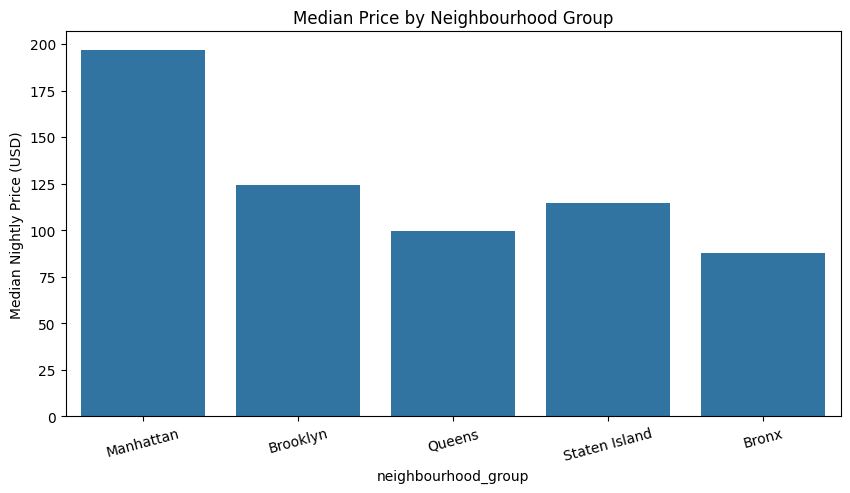

In [5]:
plt.figure(figsize=(10,5))
sns.barplot(x=nbh_grp.index, y=nbh_grp['mean_price'])
plt.title('Median Price by Neighbourhood Group')
plt.ylabel('Median Nightly Price (USD)')
plt.xticks(rotation=15)
plt.show()

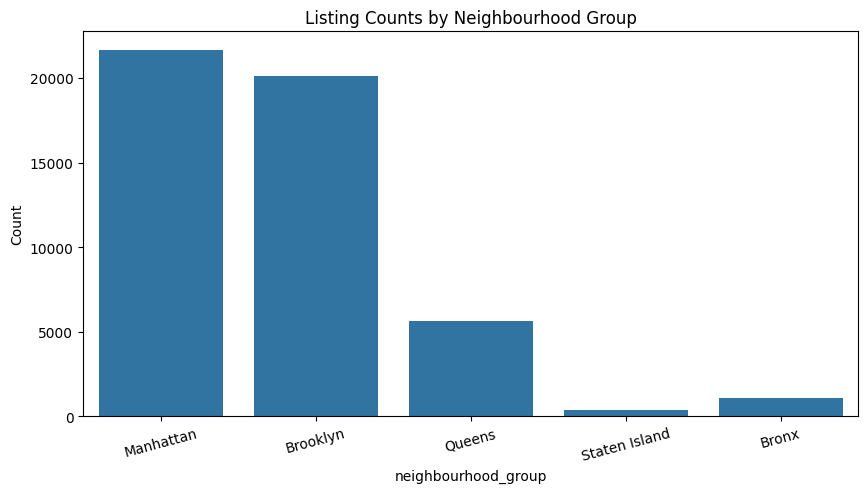

In [6]:
plt.figure(figsize=(10,5))
sns.barplot(x=nbh_grp.index, y=nbh_grp['listings'])
plt.title('Listing Counts by Neighbourhood Group')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.show()

### Most reviews
People choose to stay less time in affordable properties.

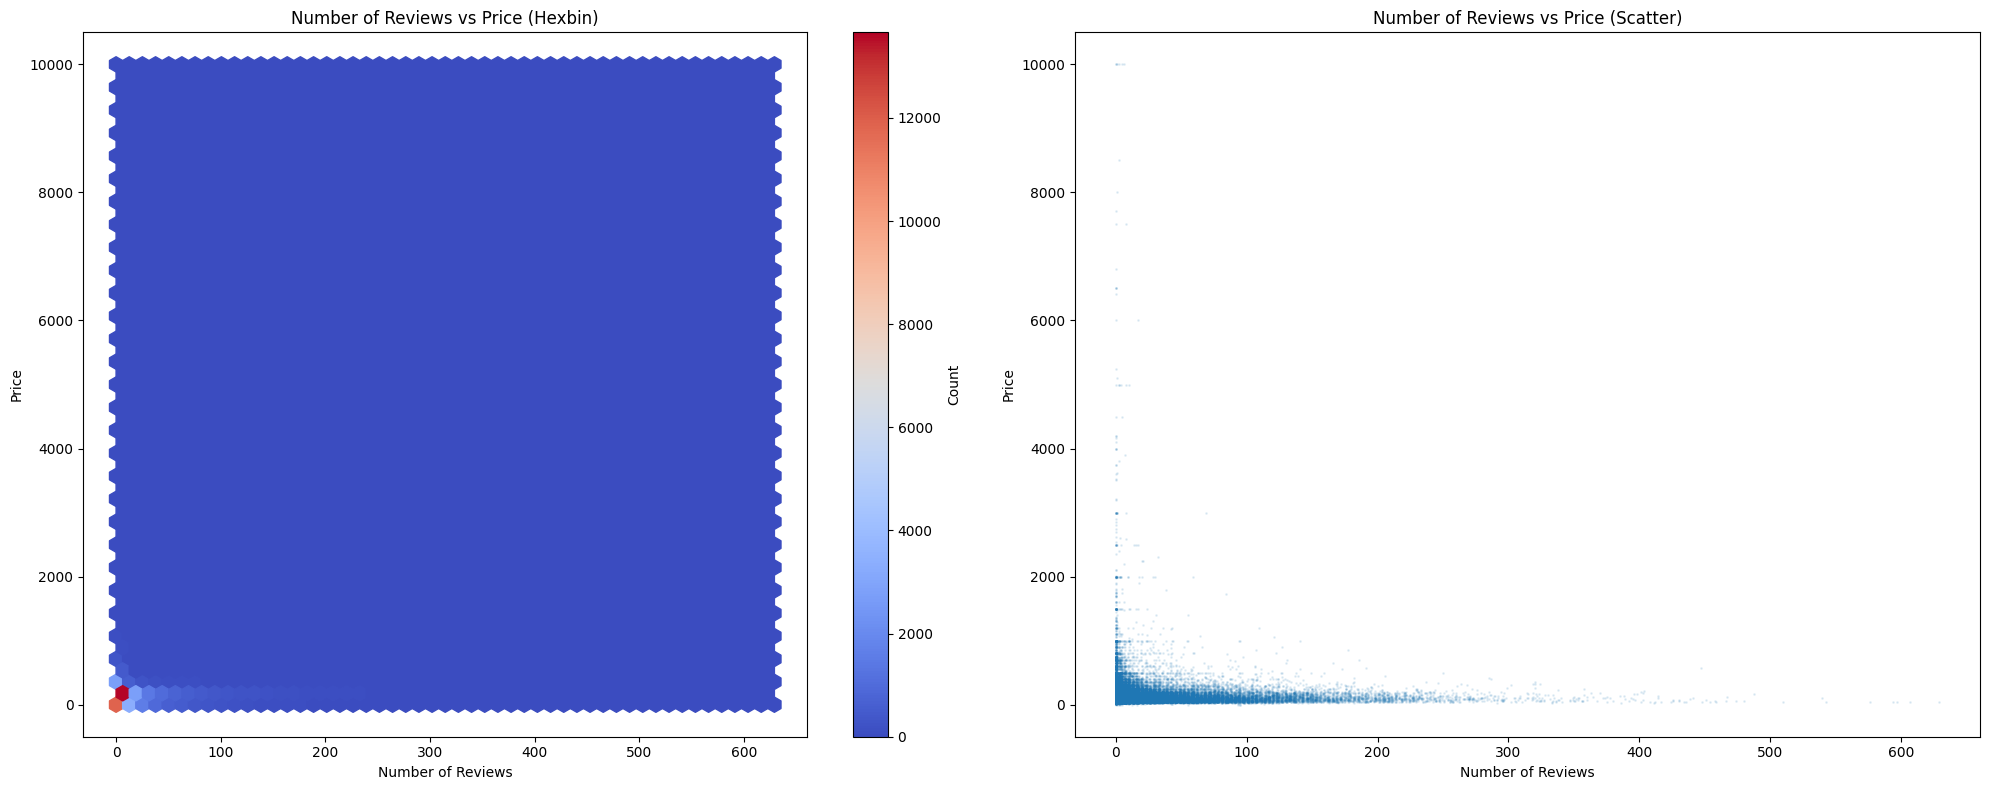

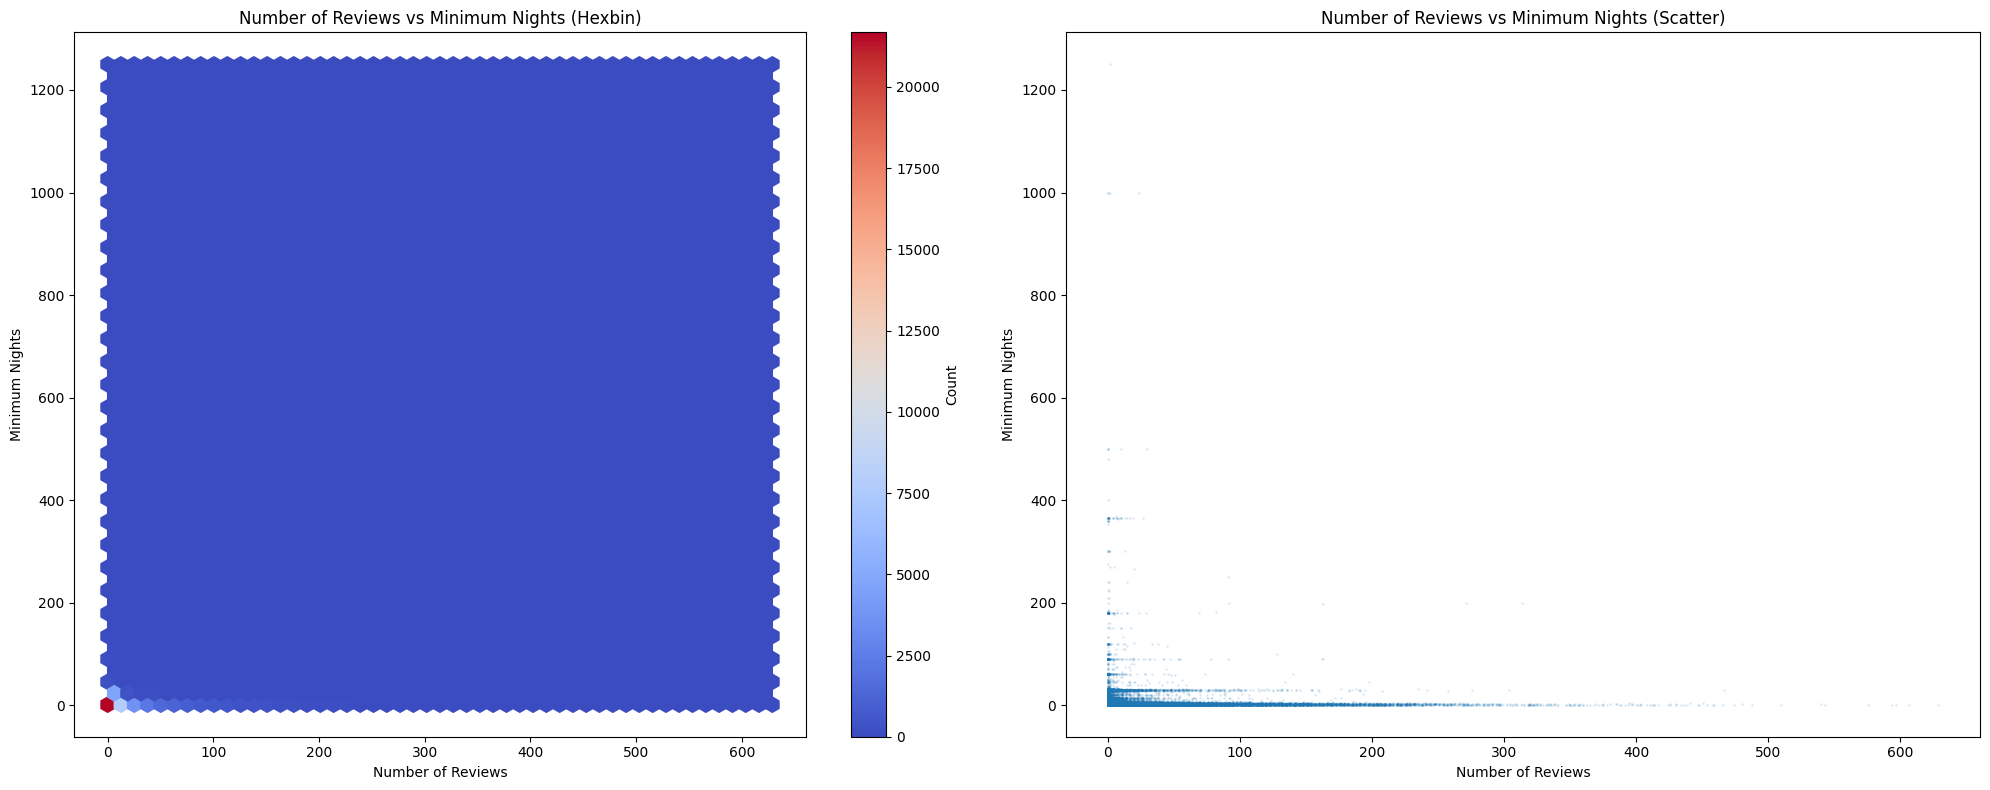

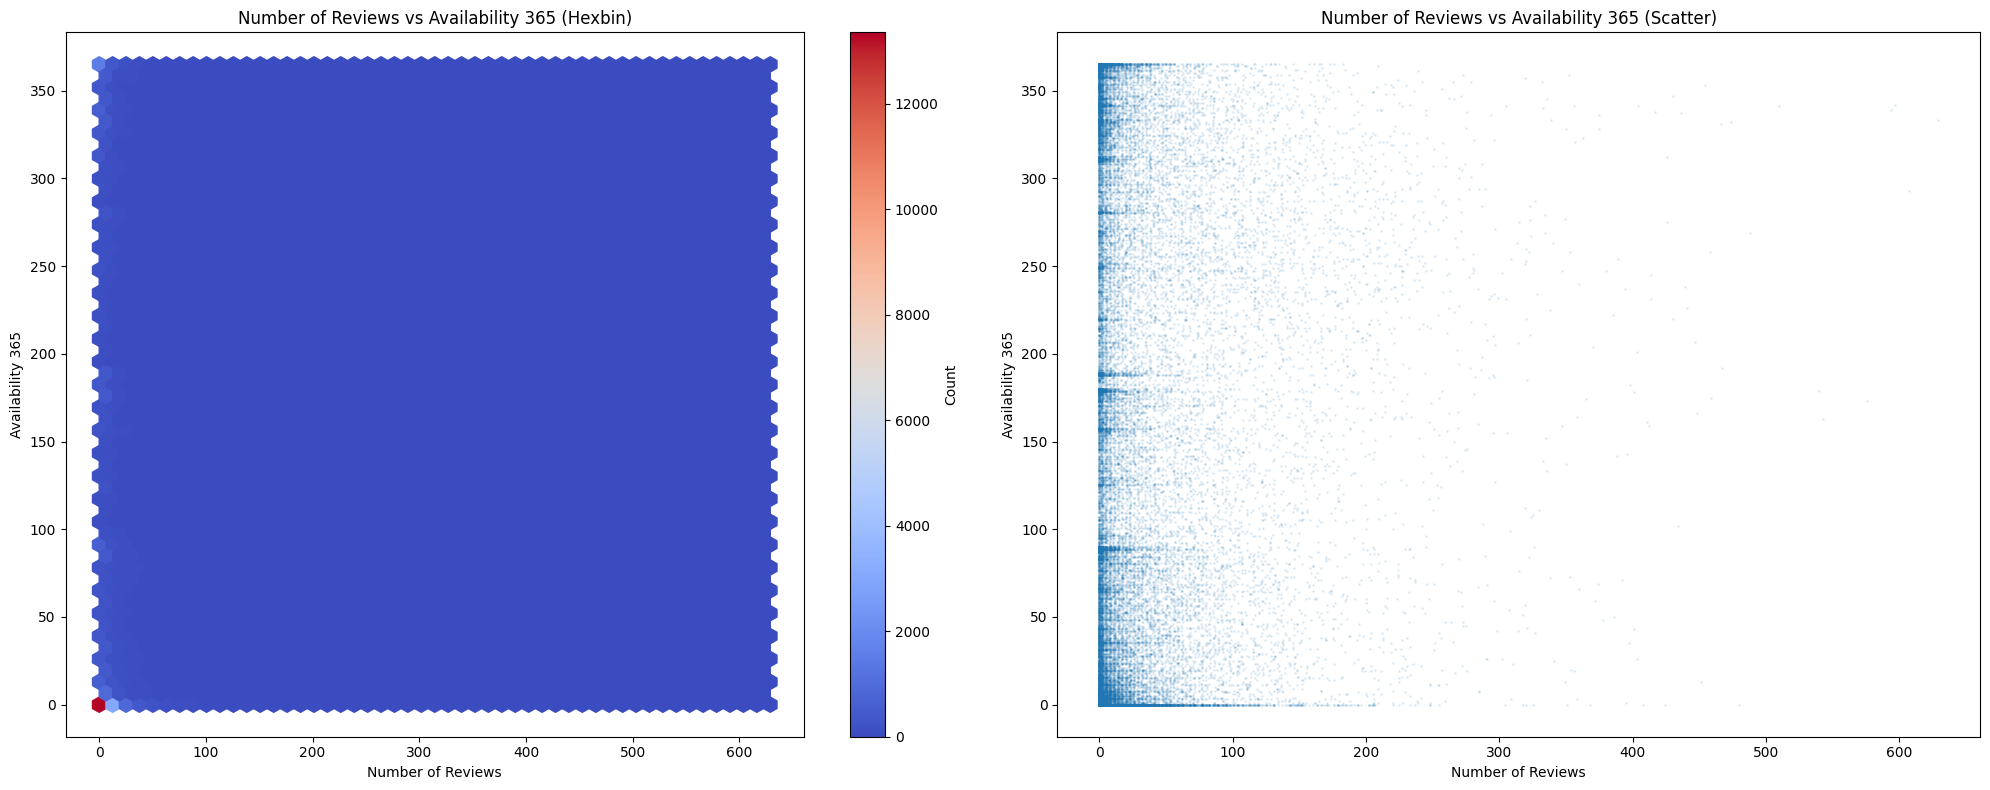

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

axes[0].hexbin(df['number_of_reviews'], df['price'], gridsize=50, cmap='coolwarm')
fig.colorbar(axes[0].collections[0], ax=axes[0], label='Count')
axes[0].set_title('Number of Reviews vs Price (Hexbin)')
axes[0].set_xlabel('Number of Reviews')
axes[0].set_ylabel('Price')

axes[1].scatter(df['number_of_reviews'], df['price'], alpha=0.1, s=1)
axes[1].set_title('Number of Reviews vs Price (Scatter)')
axes[1].set_xlabel('Number of Reviews')
axes[1].set_ylabel('Price')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

axes[0].hexbin(df['number_of_reviews'], df['minimum_nights'], gridsize=50, cmap='coolwarm')
fig.colorbar(axes[0].collections[0], ax=axes[0], label='Count')
axes[0].set_title('Number of Reviews vs Minimum Nights (Hexbin)')
axes[0].set_xlabel('Number of Reviews')
axes[0].set_ylabel('Minimum Nights')

axes[1].scatter(df['number_of_reviews'], df['minimum_nights'], alpha=0.1, s=1)
axes[1].set_title('Number of Reviews vs Minimum Nights (Scatter)')
axes[1].set_xlabel('Number of Reviews')
axes[1].set_ylabel('Minimum Nights')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

axes[0].hexbin(df['number_of_reviews'], df['availability_365'], gridsize=50, cmap='coolwarm')
fig.colorbar(axes[0].collections[0], ax=axes[0], label='Count')
axes[0].set_title('Number of Reviews vs Availability 365 (Hexbin)')
axes[0].set_xlabel('Number of Reviews')
axes[0].set_ylabel('Availability 365')

axes[1].scatter(df['number_of_reviews'], df['availability_365'], alpha=0.1, s=1)
axes[1].set_title('Number of Reviews vs Availability 365 (Scatter)')
axes[1].set_xlabel('Number of Reviews')
axes[1].set_ylabel('Availability 365')


plt.tight_layout()
plt.show()

### Numeric Feature Correlation Heatmap (Pearson)
Based on the heatmap, the strongest positive correlation is between `number_of_reviews` and `reviews_per_month` with a Pearson correlation coefficient of 0.55.
So popular listings that receive more reviews overall are likely to continue receiving reviews at a faster rate.

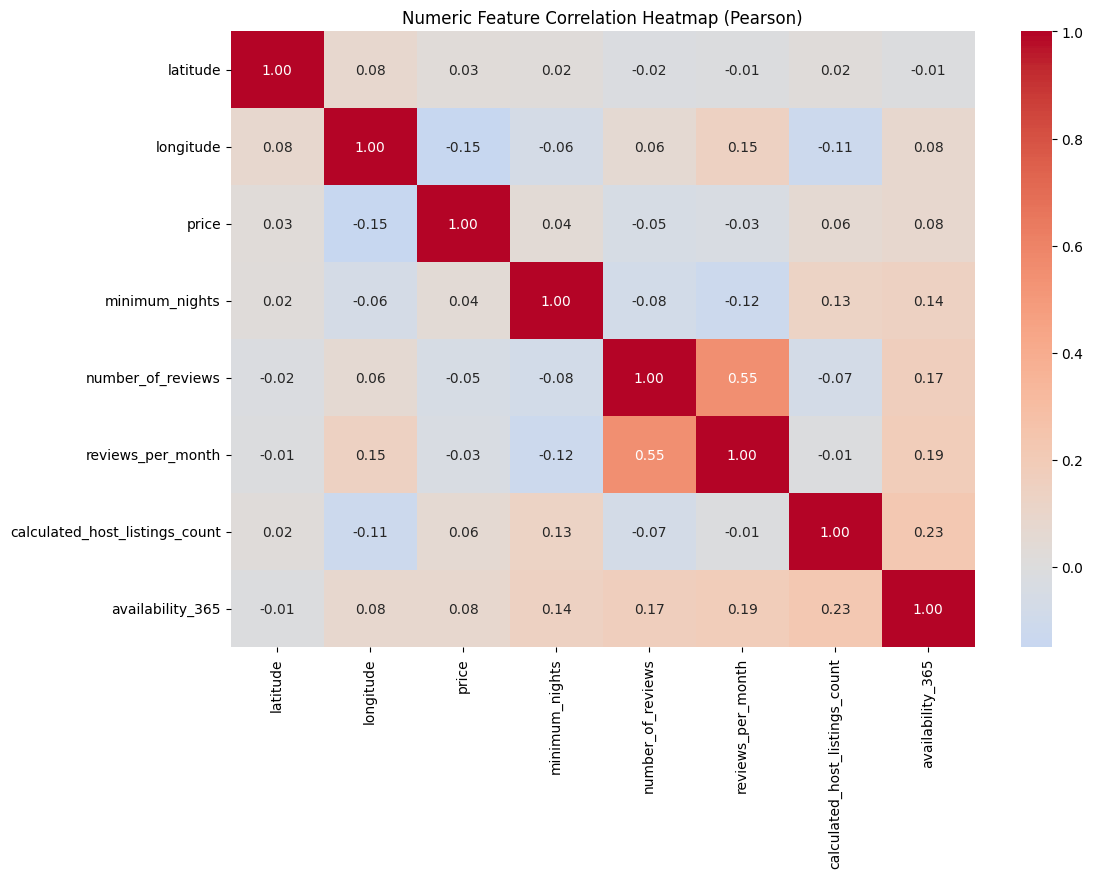

In [8]:
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=[np.number]).drop(['id', 'host_id'], axis=1)
num_corr = numeric_df.corr(method='pearson')
sns.heatmap(num_corr, cmap='coolwarm', center=0, annot=True, fmt=".2f")
plt.title('Numeric Feature Correlation Heatmap (Pearson)')
plt.show()

### Map of listings by neighborhood group
Manhattan and Brooklyn being the most crowded.

In [9]:
import pandas as pd
import plotly.express as px

fig = px.scatter_mapbox(
    df,
    lat="latitude",
    lon="longitude",
    hover_name="name",
    hover_data=["neighbourhood_group"],
    color="neighbourhood_group",
    zoom=10,
    height=700
)

fig.update_traces(
    marker=dict(
        size=4,
        opacity=0.3,
    )
)

fig.update_layout(mapbox_style="carto-positron")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.update_layout(
    legend=dict(
        orientation="h",
        yanchor="bottom",
        xanchor="center",
        x=0.5
    )
)

fig.show()

### Map of listings by room type
Since the marker size is correlated with price, it appears that entire home/apt are much denser than private rooms and shared rooms, but they account for only 51.97%. The average price of an entire home/apartment is more than double the average price of private rooms and triple the average price of shared rooms.

In [10]:
import pandas as pd
import plotly.express as px

room_type_counts = df['room_type'].value_counts(normalize=True) * 100

mean_prices = df.groupby('room_type')['price'].median()

summary = pd.DataFrame({
    "Room Type": room_type_counts.index,
    "Median Price": mean_prices,
    "Percentage (%)": room_type_counts
}).round(2)

print(summary.to_string(index=False))

fig = px.scatter_mapbox(
    df,
    lat="latitude",
    lon="longitude",
    hover_name="name",
    hover_data=["room_type", "price"],
    color="room_type",
    size="price",
    zoom=10,
    height=700
)

fig.update_layout(mapbox_style="carto-positron")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.update_layout(
    legend=dict(
        orientation="h",
        yanchor="bottom",
        xanchor="center",
        x=0.5
    )
)

fig.show()

      Room Type  Median Price  Percentage (%)
Entire home/apt         160.0           51.97
   Private room          70.0           45.66
    Shared room          45.0            2.37
